# ENCS5342 — Assignment #1
## Arabic Stemming, Lemmatization, and Regular Expressions

| | |
|---|---|
| **Course** | ENCS5342 — Information Retrieval with Applications of NLP |
| **Instructor** | Dr. Ahmed I. A. Shawahna — Birzeit University |
| **Semester** | Second Semester 2025–2026 |


| | Name | ID | Section |
|---|---|---|---|
| **Student 1** | Sawsana Atari | 1221320 | Sec2 | 
| **Student 2** | Sadeen Ryahi | 1211109 | Sec2| 

---

## Grading & Submission

This assignment covers the use of **regular expressions** and **Python** for text processing,
and the application of **Arabic stemming and lemmatization** tools to a real multilingual corpus.

- Work in **groups of two students** (from any section).
- **Run all cells** in order before submitting. Output must be visible beneath each code cell.
- Where a question asks for discussion, add your written explanation in the **Markdown cell immediately below the code cell**.
- Submit a **single Jupyter Notebook file** named `A1_ID1_ID2.ipynb` (replace ID1 and ID2 with your student IDs).

---

## Before Starting

### Corpus: UN Parallel Corpus (UNCorpus)

This assignment uses the **United Nations General Assembly Resolutions Corpus (UNCorpus)**, a corpus of UN General Assembly resolutions. The UNCorpus is a six-language parallel text in Arabic, Chinese, English, French, Russian, and Spanish. The following paper describes the corpus:

> Rafalovitch, A. & Dale, R. (2009). *United Nations General Assembly Resolutions: A Six-Language Parallel Corpus.* Proceedings of MT Summit XII, Ottawa, Canada.  
> URL: http://web.science.mq.edu.au/~rdale/publications/papers/2009/MTS-2009-Rafalovitch.pdf

The portion of the UNCorpus used in this assignment is the file **`uncorpora_plain_20090831.tmx`**. This file is referred to as the **UNCorpus** throughout this document. It is stored in TMX format (Translation Memory eXchange), an XML-based standard for parallel corpora.

> **You can download the file from the following link:** https://drive.google.com/file/d/1AS1m3uzDL6B49xN4R7k2WWqOyRxP3QpI/view?usp=sharing  
> **Before running any cells:** place `uncorpora_plain_20090831.tmx` in the **same directory** as this notebook.

### Assignment Structure

| Section | Topic | Points |
|---------|-------|--------|
| **Section A** | Regular Expressions | 70 |
| **Section B** | Arabic Stemming and Lemmatization | 30 |
| | **Total** | **100** |


---
## Setup — Run This Cell First

This cell installs all required Python packages and loads the UNCorpus into memory. All subsequent cells depend on variables defined here. **Run this cell before any other.**

In [1]:
import re, os, sys, subprocess
from collections import Counter, defaultdict

# Install required packages
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'nltk', 'tashaphyne', 'sinatools', 'matplotlib',
     '-q', '--disable-pip-version-check'],
    capture_output=True
)

import nltk
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120 #number of dots in a square inch
nltk.download('punkt', quiet=True) # tokenzie sentences into senstenses or words => text = "Hello. How are you?", ["Hello.", "How are you?"]

# ── Load corpus ───────────────────────────────────────────────────
CORPUS_FILE = 'uncorpora_plain_20090831.tmx'

if not os.path.exists(CORPUS_FILE): 
    print(f'ERROR: corpus file not found — {CORPUS_FILE}')
    print('Place the .tmx file in the same directory as this notebook.')
else:
    size_mb = os.path.getsize(CORPUS_FILE) / (1024 * 1024)
    with open(CORPUS_FILE, 'r', encoding='utf-8', errors='replace') as f:
        content   = f.read()
        f.seek(0)
        all_lines = f.readlines()
    print(f'Corpus file : {CORPUS_FILE}  ({size_mb:.1f} MB)')
    print(f'Lines loaded: {len(all_lines):,}')
    print('Setup complete.')


Corpus file : uncorpora_plain_20090831.tmx  (155.6 MB)
Lines loaded: 1,501,316
Setup complete.


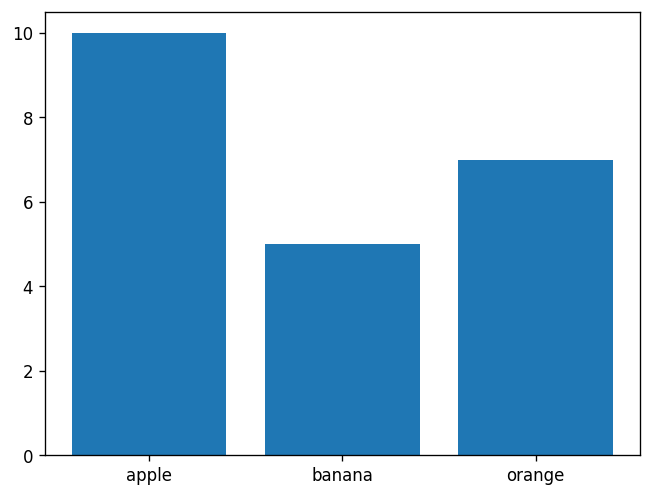

In [2]:
import matplotlib.pyplot as plt

words = ["apple", "banana", "orange"]
counts = [10, 5, 7]

plt.bar(words, counts)
plt.show()

---
# Section A: Regular Expressions (70 points)

All answers in this section must be obtained using **Python and the `re` module**. Use `re.search()`, `re.findall()`, or `re.sub()` as appropriate.

**How to present your answers:** Run the code cell for each question so that the output is visible beneath it, then write your written answer or discussion in the Markdown cell that follows.


---
### A0 (0 pt) — Worked Example: Lines Mentioning "Human Rights"

**Task:** Ignoring letter case, how many **lines** in the UNCorpus mention the phrase *Human Rights*?

This question is solved for you as a worked example illustrating the expected format: a code cell followed by a Markdown cell with the written answer.


In [5]:
# A0 — Worked example
count_hr = sum(1 for line in all_lines
               if re.search(r'human rights', line, re.IGNORECASE))
print(f'{count_hr:,} lines mention "Human Rights" (case-insensitive).')


5,664 lines mention "Human Rights" (case-insensitive).


**Answer:** 5,664 lines of text mention the phrase *Human Rights*.


---
### A1 (5 pt) — XML Structure of the UNCorpus

**Task:** Use Python and regular expressions to investigate and describe the XML structure of the UNCorpus TMX file. Your written answer must identify:

- The root element and all key container elements.
- Which element holds one complete translation unit (a sentence in all six languages).
- Which element holds one language's version of a sentence, and how the language is identified.
- Which element contains the actual text of a segment.
- Any metadata or property elements present in the file.

Include the regex patterns you used to discover each structural feature.


In [6]:
# A1 — write your code here — Investigate XML structure
# to discover the root element and all key container elements:
# pattern = r'<\btmx\b\s' # or r'<.*>'
# root_element = re.findall(pattern, content) # should re.search => to capture first or not
# print(len(root_element))
# print(root_element)

# 
# pattern = r'<(?!/).*>' # what diff with r'<.*?>'
# key_container_elements = re.findall(pattern, content)
# print(len(key_container_elements), all keys)


# to discover which element holds one complete translation unit (a sentences in six languages)
# pattern = r'<tu\b[^>]*?>[\s\S]*?</tu>' # [^>]* => take max num of char, [^>]*? => take min num of char
# translation_unit = re.findall(pattern, content)
# print(len(translation_unit), 'translation unit')
# print(translation_unit[])


# to discover which element holds one language's version of a sentence, and how the language is identified
# pattern = r'<tuv\b[^>]*?>[\s\S]*?</tuv>'
# translation_unit_lang_version = re.findall(pattern, content)
# print(len(translation_unit_lang_version))
# lang_type = re.search() # xml:lang="[A-Z]{2}"****
# lang_type = re.search(r'xml:lang="([A-Z]{2})"',translation_unit_lang_version[m])

# to discover which element holds the actual text of a segement
# pattern = r'<seg\b[^>]*?>[\s\S]*?</seg>'
# actual_text = re.findall(pattern, content)
# print(len(actual_text))

# to discover any metadat of property elements present in the file
pattern = r'<(?!/?(?:tu|tuv|seg)\b)[^>]*?>'
meta_data = re.findall(pattern, content)
print(len(meta_data), 'metadata')
print(meta_data[:20])

# what about these '<prop type="session">', '</prop>', '<prop type="committee">' <= under what written???


109042 metadata
['<?xml version="1.0" encoding="UTF-8"?>', '<tmx version="1.4b">', '<header segtype="paragraph" creationtoolversion="1.0" srclang="EN" creationtool="ORESAligner" datatype="plaintext" o-tmf="ORES" adminlang="en-us"/>', '<body>', '<prop type="session">', '</prop>', '<prop type="committee">', '</prop>', '<prop type="lead">', '</prop>', '<prop type="lead">', '</prop>', '<prop type="lead">', '</prop>', '<prop type="lead">', '</prop>', '<prop type="lead">', '</prop>', '<prop type="lead">', '</prop>']


In [7]:
sen = '<?xml version="1.0" encoding="UTF-8"?>\n'
pattern = '<.*?>'
result = re.findall(pattern, sen)
print(result)
pattern = '<.*>'
result = re.findall(pattern, sen)
print(result)

['<?xml version="1.0" encoding="UTF-8"?>']
['<?xml version="1.0" encoding="UTF-8"?>']


**Answer:**

*(Describe the XML structure here based on the output above. Include the structure diagram and explain each element.)*
Root:
transalation unit:
transalation unit version:
segment:
header, body, ?xml, tmx:
prop: ???

i will back to this later


---
### A2 (10 pt) — Corpus-Level Statistics (2.5 pt each)

Answer each sub-question using Python and regular expressions on the full UNCorpus TMX file.
Run the code cell for each part and write the answer in the Markdown cell that follows.


#### A2a — How many lines does the UNCorpus file have?

In [ ]:
# A2a — write your code here
# number_of_lines = len(all_lines)
# print(number_of_lines)

pattern = r'\n'
lines = re.findall(pattern, content)
print(len(lines), 'lines number')


1501316
1501316


**Answer:** *(1501316)*


#### A2b — How many lines contain the segment tag `<seg>`?

In [94]:
# A2b — write your code here
# p = '<seg>RESOLUTION \n55/100</seg>\n'
pattern = r'<seg>[^<]+?</seg>'
pattern = r'<\bseg\b>'#434034
pattern = r'<seg>[^\n]+\n|[^\n]+</seg>\n|<seg>[^\n]+</seg>\n' #434034
pattern = r'<seg>'
num_of_seg_lines = re.findall(pattern, content)
print(len(num_of_seg_lines), 'lines contain the segment tag <seg>')
print('just check if it is include tag:</seg> or not**')

434034 lines contain the segment tag <seg>
just check if it is include tag:</seg> or not**


**Answer:** *(434034)*


#### A2c — How many lines contain **no** `<seg>` tag?

These are lines with other tags such as `<prop>`, `</tuv>`, `<tu>`, `<header>`, etc.


In [ ]:
# A2c — write your code here
p = '<seg>RESOLUTION </seg>\n55/\n100</seg>\n'
print(p)

pattern = r'<([^s]+)>'
# num_of_no_seg = re.findall(pattern, p)
num_of_no_seg = re.findall(pattern, content)
print(len(num_of_no_seg))
print('come back to resolve this**')


**Answer:** *(write here)*


#### A2d — How many **English** segments does the UNCorpus contain?

In [ ]:
# A2d — write your code here
    #   <tuv xml:lang="EN">
    #     <seg>RESOLUTION 55/100</seg>
    #   </tuv>
pattern = r'<tuv xml:lang="EN">\s+?<seg>([\s\S]+?)</seg>\s+?</tuv>'
english_seg = re.findall(pattern, content)
print(len(english_seg))
# print(english_seg[:30])


**Answer:** *(72339)*


---
### A3 (25 pt) — The English UNCorpus

**Points:** 5 pt for the extraction setup | 4 pt each for sub-questions A3a–A3e

> **Definition:** A *word* in this section is any sequence of one or more **non-space** characters (i.e. tokens separated by whitespace). Punctuation and digits attached to a word are kept as part of it.

**Before answering A3a–A3e**, you must first extract the English plain text from the UNCorpus and save it to a file called `uncorpus.eng.txt`. This file must contain only the text content of the English segments — all XML tags must be removed.

Write your extraction code in the code cell below. Your code should follow these steps:

1. Iterate over the corpus lines and collect the `<seg>...</seg>` line that immediately follows each English TUV opening line.
2. Write the collected raw lines to `uncorpus.eng.txt`.
3. Read the file back, strip the `<seg>` and `</seg>` tags using `re.sub()`, and write the cleaned plain text back to the same file.
4. Verify your result using `os.path.getsize()`. The expected file size is **18,009,005 bytes**. If it does not match, revisit your line ending handling and tag stripping logic.

> *Note: On Linux/macOS you can also verify in a terminal with `wc -c uncorpus.eng.txt`, where `wc` stands for "word count" and the `-c` flag counts bytes.*

All sub-questions A3a–A3e use this file. At the bottom of your extraction cell, load the file into memory and split on whitespace to produce the token list used throughout A3.

In [3]:
# A3 Setup — write your extraction code here

# read 
with open("uncorpora_plain_20090831.tmx", "r", encoding="utf-8") as f:
    all_lines = f.readlines()

#   Collecte the <seg>...</seg> line that immediately follows each English TUV opening line
english_segs = []
for i in range(len(all_lines)):
    lang_line = all_lines[i].strip()
    if '<tuv xml:lang="EN">' in lang_line:
        seg_line_num = i+1
        if seg_line_num < len (all_lines):
            seg = re.search(r'<seg>[\s\S]+?</seg>', all_lines[seg_line_num].strip())
            if seg:
                english_segs.append(seg.group())


# Write the collected raw lines to uncorpus.eng.txt
with open("uncorpus.eng.txt", "w", encoding="utf-8", newline="\n") as f:
    for seg in english_segs:
        f.write(seg + "\n")

# Read the file back
with open("uncorpus.eng.txt", "r", encoding="utf-8") as f:
    all_lines_with_seg = f.readlines()

# Strip the <seg> and </seg> tags using re.sub()
pattern = r'(</?seg>)'
clean_lines = []
for line in all_lines_with_seg:
    clean_lines.append(re.sub(pattern, '', line))

# Write the cleaned plaintext back to the same file
with open("uncorpus.eng.txt", "w", encoding="utf-8", newline="\n") as f:
    for line in clean_lines:
        f.write(line)


# Verify that the expected file size is **18,009,005 bytes**
UNCORPUS_ENG_FILE = 'uncorpus.eng.txt'
size_b = os.path.getsize(UNCORPUS_ENG_FILE)# / (1024 * 1024)
print(f'UNCORPUS ENG file : {UNCORPUS_ENG_FILE}  ({size_b:.1f}) bytes')



UNCORPUS ENG file : uncorpus.eng.txt  (18009005.0) bytes


#### A3a — How many word tokens does `uncorpus.eng.txt` contain?

In [ ]:
# A3a — write your code here
# token is defined above as => 


**Answer:** *(write here)*


#### A3b — How many unique word types does the file contain?

In [ ]:
# A3b — write your code here
# think about to use set {}


**Answer:** *(write here)*


#### A3c — How many unique word types remain after ignoring capitalization?

In [15]:
# A3c — write your code here



**Answer:** *(write here)*


#### A3d — How many tokens consist **entirely of digits**? (e.g. `9000`)


In [16]:
# A3d — write your code here



**Answer:** *(write here)*


#### A3e — How many tokens contain digits **and** at least one non-alphabetic character, but **no letters**? (e.g. `8,000.00` or `8-8`)

These are tokens that mix digits with punctuation characters such as commas, hyphens, or periods, but contain no letters.


In [17]:
# A3e — write your code here



**Answer:** *(write here)*


---
### A4 (15 pt) — War and Peace in the UN (3 pt setup + 3 pt each)

This question uses `uncorpus.eng.txt`.
For all sub-questions, **ignore letter case and all non-alphabetic characters** — work with letters only.

**Before answering A4a–A4d**, write the setup code in the cell below. Your setup should:

1. Extract all alphabetic-only tokens from `uncorpus.eng.txt` using `re.findall()`.
2. Build a set of unique lowercased types from those tokens.
3. Print the total number of unique alphabetic word types as a sanity check. The expected number is 11,253 words.


In [4]:
# A4 Setup — Alphabetic-only tokens (letters only)
with open("uncorpus.eng.txt", "r", encoding="utf-8") as f:

    eng_text = f.read()

# Extract only purely alphabetic tokens

alpha_tokens = re.findall(r'[a-zA-Z]+', eng_text)

# Build set of unique lowercased types

alpha_types = set(t.lower() for t in alpha_tokens)

print(f'Total alphabetic tokens : {len(alpha_tokens):,}')

print(f'Unique alphabetic types : {len(alpha_types):,}')  # Expected: 11,253

Total alphabetic tokens : 2,618,341
Unique alphabetic types : 11,253


#### A4a — How many unique words **contain** the substring `war`?

In [5]:
# A4a — Unique words that CONTAIN 'war'

contain_war = {w for w in alpha_types if re.search(r'war', w)}

print(f'Words containing "war": {len(contain_war)}')

print(sorted(contain_war))

Words containing "war": 43
['afterwards', 'award', 'awarded', 'awarding', 'awards', 'aware', 'awareness', 'backwardness', 'downward', 'forward', 'forwarded', 'forwarding', 'freeware', 'hardware', 'outward', 'reward', 'rewards', 'software', 'stewardship', 'thwarting', 'toward', 'towards', 'upward', 'war', 'wardship', 'warehouse', 'warfare', 'warhead', 'warheads', 'warlords', 'warm', 'warmly', 'warning', 'warnings', 'warrant', 'warranted', 'warranting', 'warrants', 'warring', 'wars', 'warsaw', 'warship', 'warships']


**Answer:** 43 unique words contain the substring *war* (e.g., war, warring, aware, reward, forward).


#### A4b — How many unique words **start with the substring** `war`?

In [6]:
# A4b — Unique words that START WITH 'war'

start_war = {w for w in alpha_types if re.match(r'^war', w)}

print(f'Words starting with "war": {len(start_war)}')

print(sorted(start_war))

Words starting with "war": 20
['war', 'wardship', 'warehouse', 'warfare', 'warhead', 'warheads', 'warlords', 'warm', 'warmly', 'warning', 'warnings', 'warrant', 'warranted', 'warranting', 'warrants', 'warring', 'wars', 'warsaw', 'warship', 'warships']


**Answer:** 20 unique words start with the substring *war* (e.g., war, warfare, warning).


#### A4c — How many unique words **end with the substring** `war`?

In [7]:
# A4c —  Unique words that END WITH 'war'

end_war = {w for w in alpha_types if re.search(r'war$', w)}

print(f'Words ending with "war": {len(end_war)}')

print(sorted(end_war))

Words ending with "war": 1
['war']


**Answer:** 1 unique words end with the substring *war*.


#### A4d — How many unique words **contain the substring** `war` but **neither start nor end** with it?


In [8]:
# A4d —'war' in middle only (not at start, not at end)

middle_war = {w for w in alpha_types

              if re.search(r'war', w)

              and not re.match(r'^war', w)

              and not re.search(r'war$', w)}

print(f'Words with "war" in middle only: {len(middle_war)}')

print(sorted(middle_war))

Words with "war" in middle only: 23
['afterwards', 'award', 'awarded', 'awarding', 'awards', 'aware', 'awareness', 'backwardness', 'downward', 'forward', 'forwarded', 'forwarding', 'freeware', 'hardware', 'outward', 'reward', 'rewards', 'software', 'stewardship', 'thwarting', 'toward', 'towards', 'upward']


**Answer:** 23 unique words contain *war* in a position that is neither the beginning nor the end (e.g., award, stewardship, toward).

---
### A5 (10 pt) — Word Frequency Histogram

This question uses `uncorpus.eng.txt`.

A **frequency histogram** is a list of all words sorted by how often they appear. It is one of the most fundamental tools in corpus linguistics and is the basis of Zipf's Law — the observation that word frequency drops sharply after the top few words, following a power-law distribution.

> **Definition:** A *word* here is any whitespace-separated token (keep all punctuation and digits; split on whitespace only).

**Tasks:**
1. Build the frequency table (word → count) for all tokens.
2. Report the **10 most frequent words** (top 10) with their counts and percentage of the corpus.
3. Report **10 hapax legomena** — words appearing exactly once. Report also the total hapax count and what fraction of the vocabulary they represent.
4. Plot a **bar chart** of the top 20 words by frequency.
5. **Discuss in 2–3 sentences:** What do the top 10 words have in common? What NLP concept does this illustrate?

**Points:** 3 pt for the top-10 frequency table | 3 pt for hapax analysis | 3 pt for the bar chart | 1 pt for discussion.


In [9]:
# A5 — Word Frequency Histogram

with open("uncorpus.eng.txt", "r", encoding="utf-8") as f:

    eng_text = f.read()

all_tokens = eng_text.split()

freq = Counter(all_tokens)

total_tokens = len(all_tokens)

vocab_size   = len(freq)

# Top 10 most frequent words
print("=" * 62)

print(f"{'Rank':<6} {'Word':<20} {'Count':>10} {'% corpus':>12}")

print("=" * 62)

for rank, (word, count) in enumerate(freq.most_common(10), 1):

    pct = count / total_tokens * 100

    print(f"{rank:<6} {word:<20} {count:>10,} {pct:>11.2f}%")

# Hapax legomena 
hapax = [w for w, c in freq.items() if c == 1]

print(f"\nTotal hapax legomena : {len(hapax):,}")

print(f"Hapax / vocabulary   : {len(hapax)/vocab_size*100:.1f}%")

print("\n10 sample hapax legomena:")

for w in hapax[:10]:

    print(f"  {w}")

Rank   Word                      Count     % corpus
1      the                     267,940        9.98%
2      of                      175,497        6.53%
3      and                     136,607        5.09%
4      to                       99,545        3.71%
5      in                       66,802        2.49%
6      on                       35,910        1.34%
7      for                      32,327        1.20%
8      that                     22,534        0.84%
9      its                      21,181        0.79%
10     with                     20,349        0.76%

Total hapax legomena : 13,527
Hapax / vocabulary   : 36.5%

10 sample hapax legomena:
  55/100.
  54/169
  55/101
  55/101.
  55/102.
  55/103.
  53/150
  2000/37
  55/104
  55/104.


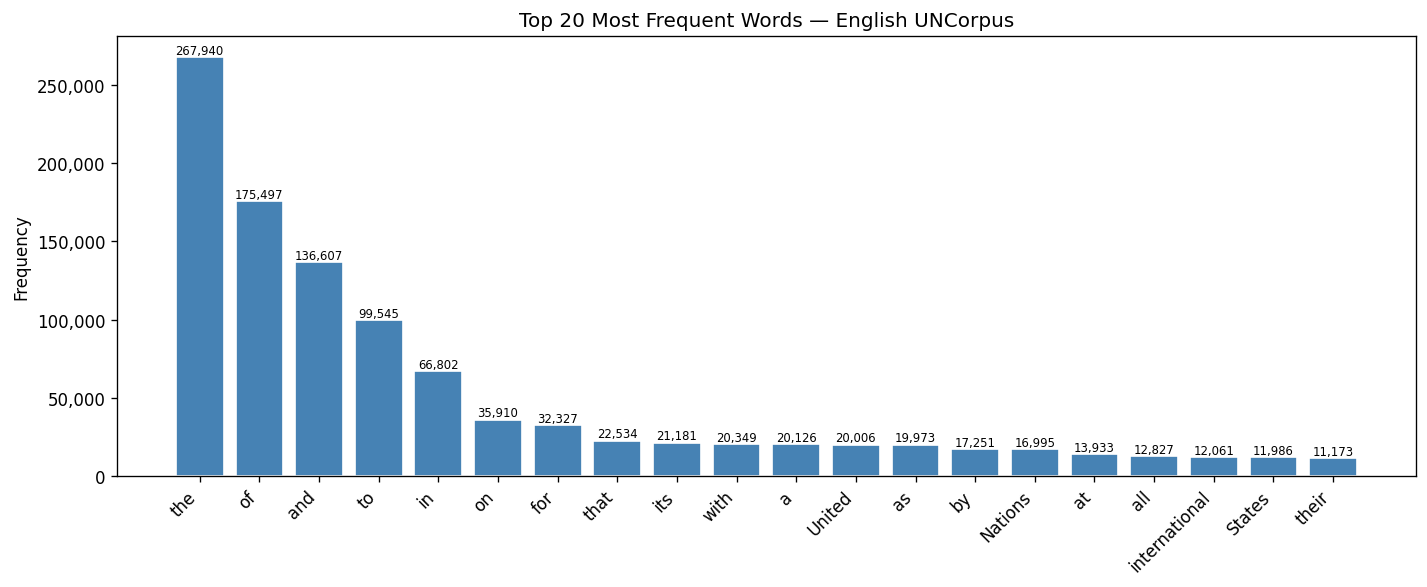

In [10]:
# A5 — Bar chart of top 20 words

top20 = freq.most_common(20)

words20, counts20 = zip(*top20)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(range(len(words20)), counts20, color='steelblue', edgecolor='white')

ax.set_xticks(range(len(words20)))

ax.set_xticklabels(words20, rotation=45, ha='right', fontsize=10)

ax.set_ylabel('Frequency')

ax.set_title('Top 20 Most Frequent Words — English UNCorpus')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, count in zip(bars, counts20):

    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,

            f'{count:,}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()

plt.show()

**Discussion:** The top 10 words are mostly function words such as *the*, *of*, *and*, *to*, and *in*, which appear very frequently in the corpus. For example, the word *the* alone appears 267,940 times (about 9.98%), showing how a few words dominate the text. This follows Zipf’s Law, where a small number of words are very common, while many others (like the hapax legomena = 36.5%) appear only once. These common words are usually removed in information retrieval because they do not carry strong meaning.

---
### A6 (5 pt) — Top 20 Words per Language

Go back to the **original UNCorpus TMX file** for this question.

For each of the four languages — **English** (`en`), **Arabic** (`ar`), **Spanish** (`es`), and **Russian** (`ru`) — extract all segment text and find the **top 20 most frequent words**.

> **Definition:** A *word* is any whitespace-separated token. Keep all punctuation and digits; do **not** apply any regex filtering — split only on whitespace.

**Tasks:**
1. Display a top-20 frequency table for each language.
2. Plot a **bar chart** of the top 20 words for each language.
3. **Discuss in 2–3 sentences** per language: What do the top words reveal about that language's grammatical structure? (Consider function words, clitics, articles, and prepositions.)

**Points:** 2 pt for the four frequency tables | 2 pt for the four bar charts | 1 pt for discussion.


In [11]:
# A6 — Top 20 words per language — frequency tables

lang_map = {

    'EN': 'English',

    'AR': 'Arabic',

    'ES': 'Spanish',

    'RU': 'Russian'

}

lang_freqs = {}

for lang_code, lang_name in lang_map.items():

    pattern = rf'<tuv xml:lang="{lang_code}"[^>]*>\s*<seg>([\s\S]*?)</seg>'

    segs = re.findall(pattern, content, re.IGNORECASE)

    text = ' '.join(segs)

    tokens = text.split()

    lang_freqs[lang_code] = Counter(tokens)

    top20 = lang_freqs[lang_code].most_common(20)

    print(f"\n{'='*52}")

    print(f"  Top 20 — {lang_name} ({lang_code})")

    print(f"{'='*52}")

    print(f"{'Rank':<6} {'Word':<28} {'Count':>10}")

    print(f"{'-'*52}")

    for rank, (w, c) in enumerate(top20, 1):

        print(f"{rank:<6} {w:<28} {c:>10,}")


  Top 20 — English (EN)
Rank   Word                              Count
----------------------------------------------------
1      the                             267,940
2      of                              175,497
3      and                             136,607
4      to                               99,545
5      in                               66,802
6      on                               35,910
7      for                              32,327
8      that                             22,534
9      its                              21,181
10     with                             20,349
11     a                                20,126
12     United                           20,006
13     as                               19,973
14     by                               17,251
15     Nations                          16,995
16     at                               13,933
17     all                              12,827
18     international                    12,061
19     States                

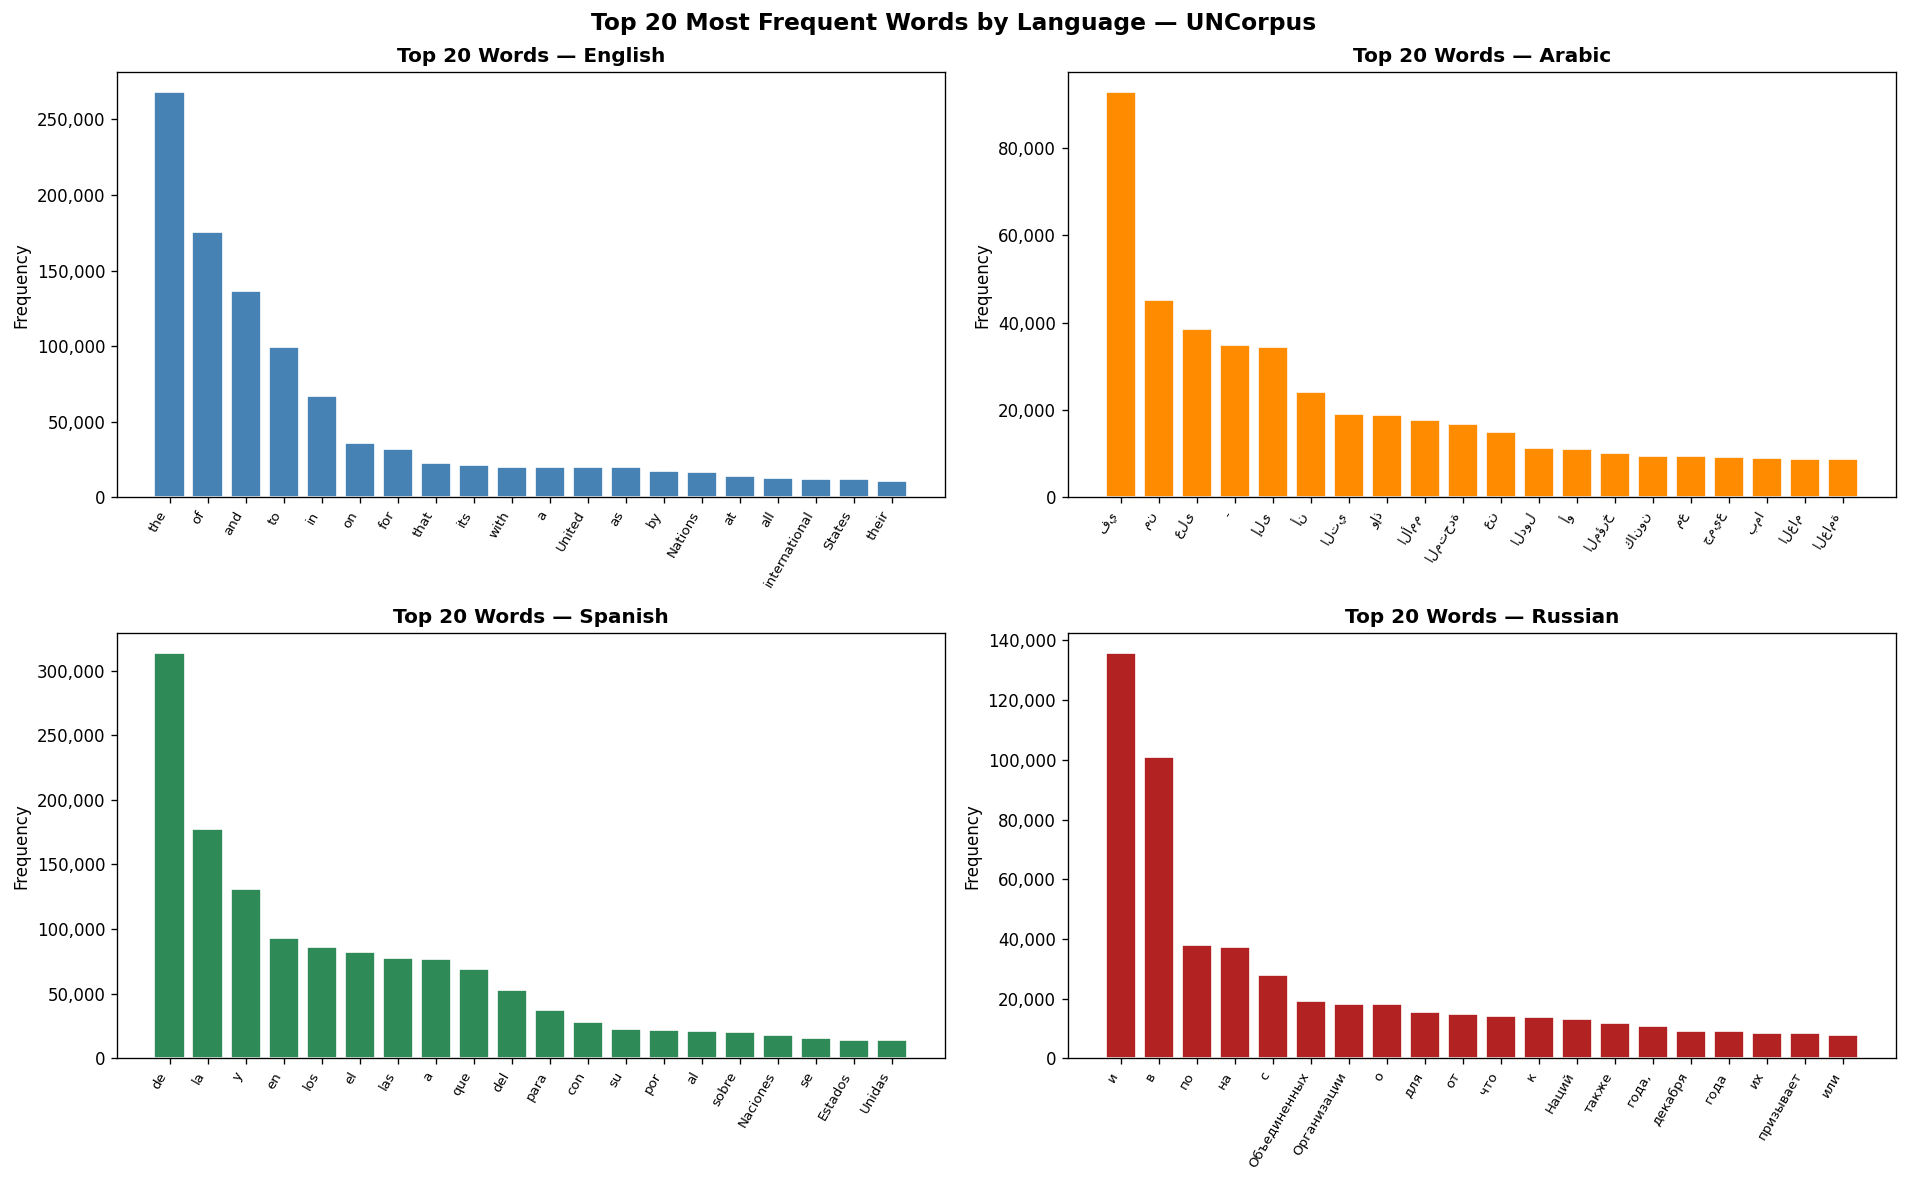

In [12]:
# A6 — Bar charts for all four languages

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

colors = {'EN': 'steelblue', 'AR': 'darkorange', 'ES': 'seagreen', 'RU': 'firebrick'}

lang_names = {'EN': 'English', 'AR': 'Arabic', 'ES': 'Spanish', 'RU': 'Russian'}

for ax, (lang_code, lang_name) in zip(axes, lang_names.items()):

    top20 = lang_freqs[lang_code].most_common(20)

    words_l, counts_l = zip(*top20)

    ax.bar(range(20), counts_l, color=colors[lang_code], edgecolor='white')

    ax.set_xticks(range(20))

    ax.set_xticklabels(words_l, rotation=60, ha='right', fontsize=8)

    ax.set_title(f'Top 20 Words — {lang_name}', fontsize=12, fontweight='bold')

    ax.set_ylabel('Frequency')

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Top 20 Most Frequent Words by Language — UNCorpus', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()

**Discussion:**

**English:** The most frequent words are function words like *the*, *of*, *and*, and *to*. These words appear very often because English depends on word order and small grammatical words to build meaning. This shows that common words dominate the corpus, while content words appear less frequently.

**Arabic:** The most common words include particles like *في* (in), *من* (from), and *على* (on), as well as words with attached prefixes like *و* (and). Arabic is morphologically rich, so many grammatical meanings are added as prefixes or suffixes to words. This makes some tokens very frequent even if they are attached to different words.

**Spanish:** The top words are mainly articles and prepositions such as *de*, *la*, *y*, and *en*. Spanish uses gendered articles (*el*, *la*, *los*, *las*), which increases their frequency in the corpus. Like English, these function words are very common and carry grammatical meaning more than content.

**Russian:** The most frequent words are mostly prepositions and conjunctions like *и* (and), *в* (in), and *на* (on). Russian does not use articles, and it relies heavily on word endings (inflections) to show grammatical roles. Therefore, prepositions and connectors appear more often instead of articles.

---
# Section B: Arabic Stemming and Lemmatization (30 points)

This section works with the **Arabic segments** of the UNCorpus. You will extract the Arabic text using regular expressions (building on what you learned in Section A), initialize the stemming and lemmatization tools, and analyze the results.

**Tools you will use:**

| Tool | Type | How to import |
|------|------|---------------|
| NLTK ISRI | Root-based stemmer (no dictionary) | `from nltk.stem.isri import ISRIStemmer` |
| Tashaphyne | Light stemmer + root extractor | `from tashaphyne.stemming import ArabicLightStemmer` |
| Light10 | Light stemmer — affix stripping (Larkey et al., 2002) | Implemented below |
| Alma (SinaTools) | True lemmatizer + POS tagger — SinaLab, Birzeit University | `from sinatools.morphology import morph_analyzer` |


---
### B0 (0 pt) — Extract Arabic Text and Initialize Tools

Run this cell before attempting any question in Section B.

**Your task:** Write the regex pattern to extract all Arabic segment texts from the UNCorpus. Use the same approach as A3, but target the Arabic language code `"AR"` instead of `"EN"`. The rest of the cell — stemmer initialization and Alma setup — is provided for you.


In [13]:
# B0 — Extract Arabic segments and initialize all tools

ar_segments = re.findall(
    r'<tuv xml:lang="AR"[^>]*>\s*<seg>([\s\S]*?)</seg>',
    content, flags=re.DOTALL | re.IGNORECASE
)
ar_segments = [s.strip() for s in ar_segments if s.strip()]
ar_text     = ' '.join(ar_segments)

# Extract Arabic word tokens (Unicode Arabic block: U+0600–U+06FF)
ar_words = re.findall(r'[\u0600-\u06FF]+', ar_text)

print(f'Arabic segments extracted : {len(ar_segments):,}')
print(f'Arabic word tokens        : {len(ar_words):,}')
print(f'Arabic word types         : {len(set(ar_words)):,}')
print(f'Sample: {ar_segments[0][:100]}')

# ── Initialize stemmers (provided) ────────────────────────────────────────────
from nltk.stem.isri import ISRIStemmer
from tashaphyne.stemming import ArabicLightStemmer

isri_stemmer = ISRIStemmer()
tash_stemmer = ArabicLightStemmer()

class Light10Stemmer:
    """Reference implementation of the Light10 Arabic stemmer (Larkey et al., 2002)."""
    def __init__(self):
        self.prefixes   = ['وال', 'بال', 'كال', 'فال', 'لل', 'ال']
        self.suffixes   = ['ها', 'ان', 'ات', 'ون', 'ين', 'يه', 'ية', 'ه', 'ة', 'ي']
        self.diacritics = re.compile(r'[\u064B-\u0652\u0670]')
        self.hamza_map  = str.maketrans('أإآ', 'ااا')
    def stem(self, word):
        word = self.diacritics.sub('', word).translate(self.hamza_map)
        if len(word) > 3 and word[0] == 'و':
            word = word[1:]
        for p in sorted(self.prefixes, key=len, reverse=True):
            if word.startswith(p) and len(word) - len(p) >= 2:
                word = word[len(p):]; break
        for s in sorted(self.suffixes, key=len, reverse=True):
            if word.endswith(s) and len(word) - len(s) >= 2:
                word = word[:-len(s)]; break
        return word

light10 = Light10Stemmer()

# ── Alma (SinaTools) — downloads data files on first run ──────────────────────
ALMA_AVAILABLE = False
try:
    from sinatools.DataDownload.downloader import download_file, urls, get_appdatadir
    _app_dir  = get_appdatadir()
    _required = {
        'lemmas_dic.pickle':   'morph',
        'two_grams.pickle':    'two_grams',
        'three_grams.pickle':  'three_grams',
        'four_grams.pickle':   'four_grams',
        'five_grams.pickle':   'five_grams',
    }
    for fname, key in _required.items():
        if not os.path.exists(os.path.join(_app_dir, fname)):
            download_file(urls[key])
    from sinatools.morphology import morph_analyzer
    morph_analyzer.analyze('كتب')   # smoke test
    ALMA_AVAILABLE = True
    print('\nTools ready: ISRI | Tashaphyne | Light10 | Alma')
except Exception as e:
    print(f'\nTools ready: ISRI | Tashaphyne | Light10')
    print(f'Alma not available: {e}')
    print('Use the online demo: https://sina.birzeit.edu/alma/')

Arabic segments extracted : 72,339
Arabic word tokens        : 2,231,537
Arabic word types         : 56,552
Sample: القرار 55/100
lemmas_dic.pickle


100%|██████████| 880M/880M [01:12<00:00, 12.1MiB/s] 


Done: .pickle
two_grams.pickle


100%|██████████| 22.7M/22.7M [00:03<00:00, 7.06MiB/s]


Done: .pickle
three_grams.pickle


...

Done: .pickle
four_grams.pickle


100%|██████████| 1.22M/1.22M [00:00<00:00, 5.25MiB/s]


Done: .pickle
five_grams.pickle


100%|██████████| 430k/430k [00:00<00:00, 3.56MiB/s]


Done: .pickle

Tools ready: ISRI | Tashaphyne | Light10 | Alma


---
### B1 (8 pt) — Vocabulary Reduction by Stemming

A primary motivation for stemming in Information Retrieval is **vocabulary reduction**: grouping different surface forms of the same word under a single stem reduces the index size and improves recall by matching words that share a common root.

**Tasks:**
1. Apply **ISRI**, **Tashaphyne**, and **Light10** to all Arabic word tokens extracted in B0.
2. For each stemmer, compute the number of unique stems produced and the vocabulary reduction percentage relative to the original unstemmed vocabulary.
3. Display the results in a comparison table.
4. **Discuss in 3–4 sentences:** Which stemmer is most aggressive (reduces vocabulary the most)? Which is most conservative? What are the trade-offs between aggressiveness and precision for IR?


In [14]:
# B1 — Vocabulary Reduction by Stemming

original_types = set(ar_words)

original_count = len(original_types)

# Apply all three stemmers to every unique word type

isri_stems    = {w: isri_stemmer.stem(w)     for w in original_types}

tash_stems    = {w: tash_stemmer.light_stem(w) for w in original_types}

light10_stems = {w: light10.stem(w)           for w in original_types}

isri_unique    = len(set(isri_stems.values()))

tash_unique    = len(set(tash_stems.values()))

light10_unique = len(set(light10_stems.values()))

def pct_reduction(orig, after):

    return (orig - after) / orig * 100

print(f"\n{'Stemmer':<15} {'Unique Stems':>14} {'Reduction %':>13}")

print("-" * 45)

print(f"{'Original (none)':<15} {original_count:>14,} {'—':>13}")

print(f"{'ISRI':<15} {isri_unique:>14,} {pct_reduction(original_count, isri_unique):>12.1f}%")

print(f"{'Tashaphyne':<15} {tash_unique:>14,} {pct_reduction(original_count, tash_unique):>12.1f}%")

print(f"{'Light10':<15} {light10_unique:>14,} {pct_reduction(original_count, light10_unique):>12.1f}%")


Stemmer           Unique Stems   Reduction %
---------------------------------------------
Original (none)         56,552             —
ISRI                    20,082         64.5%
Tashaphyne              24,505         56.7%
Light10                 30,743         45.6%


**Discussion:** ISRI achieves the highest reduction (64.5%) because it performs aggressive root extraction, collapsing many surface forms into a smaller set of stems. Tashaphyne provides a moderate level of reduction (56.7%) by removing common prefixes and suffixes without fully reducing words to their roots. Light10 produces the lowest reduction (45.6%), as it applies lighter normalization and preserves more lexical variation. This reflects the typical trade-off in text processing, where stronger normalization improves recall but may negatively impact precision due to overgeneralization.

---
### B2 (7 pt) — Stemming Consistency: Do Stemmers Agree?

Different stemmers often produce different stems for the same word, which directly affects retrieval results — two documents about the same topic may not be matched if different stemmers normalize the query and document words differently.

**Tasks:**
1. Take the **50 most frequent Arabic word types** in the UNCorpus.
2. Apply **ISRI**, **Tashaphyne**, and **Light10** to each.
3. Display a table showing: word | frequency | ISRI stem | Tashaphyne stem | Light10 stem | agree?
4. Report how many of the top-50 words show full agreement across all three stemmers.
5. **Discuss in 2–3 sentences:** For words where the stemmers disagree, which stemmer produced the most useful stem for IR? Justify your answer with one specific example.


In [15]:
# B2 — Stemming Consistency on Top-50 Arabic Words

ar_freq = Counter(ar_words)

top50   = ar_freq.most_common(50)

agree_count = 0

print(f"{'Word':<22} {'Freq':>8}  {'ISRI':<18} {'Tashaphyne':<18} {'Light10':<18} {'Agree?'}")

print("-" * 100)

for word, freq_val in top50:

    i_stem = isri_stemmer.stem(word)

    t_stem = tash_stemmer.light_stem(word)

    l_stem = light10.stem(word)

    agree  = '✓' if (i_stem == t_stem == l_stem) else '✗'

    if agree == '✓':

        agree_count += 1

    print(f"{word:<22} {freq_val:>8,}  {i_stem:<18} {t_stem:<18} {l_stem:<18} {agree}")

print(f"\nFull agreement on {agree_count} / 50 words ({agree_count*2}%)")

Word                       Freq  ISRI               Tashaphyne         Light10            Agree?
----------------------------------------------------------------------------------------------------
في                       92,705  في                 في                 في                 ✓
من                       45,262  من                 من                 من                 ✓
على                      38,552  على                على                على                ✓
إلى                      34,486  الى                إلى                الى                ✗
،                        29,584  ،                  ،                  ،                  ✓
أن                       24,232  ان                 أن                 ان                 ✗
التي                     18,994  التي               التي               تي                 ✗
وإذ                      18,947  وإذ                إذ                 واذ                ✗
الأمم                    17,777  امم                أمم           

**Discussion:** The stemmers show relatively low agreement (46%), which reflects their different levels of aggressiveness and normalization strategies. In many disagreement cases, Light10 tends to produce more meaningful stems for IR, as it removes common affixes without over-reducing the word. For example, the word *المتحدة* is reduced by Light10 to *متحد*, which preserves its semantic meaning, while more aggressive stemmers may produce overly short or less informative roots.

---
### B3 (8 pt) — Stemming vs. Lemmatization on UN Political Terms

UN General Assembly resolutions use a specialized political and legal vocabulary. Stemmers may handle these technical terms differently from everyday words, and lemmatization — which maps each word to its dictionary headword — may be more appropriate for this domain.

**Tasks:** Apply all four tools to the following 15 politically significant Arabic terms that commonly appear in UN resolutions:

```
الأمم، المتحدة، الأمن، السلام، الحقوق، الإنسانية، القرار، التنمية،
الديمقراطية، الاحتلال، الإرهاب، المفاوضات، الاستقلال، السيادة، العدالة
```

1. Apply **ISRI**, **Tashaphyne**, and **Light10** to each word.
2. If Alma is available in your environment, apply it and include the diacritized lemma. Otherwise, look up each word at [sina.birzeit.edu/alma](https://sina.birzeit.edu/alma/) and fill in the Alma column manually.
3. Display a comparison table.
4. **Discuss in 3–4 sentences:** For a retrieval system operating on UN Arabic documents, which tool would you recommend and why? Address both precision (not merging unrelated words) and recall (grouping genuinely related word forms).


In [ ]:
# B3 — write your code here — Political terms: stemmers vs. lemmatizer
political_words = [
    'الأمم', 'المتحدة', 'الأمن', 'السلام', 'الحقوق',
    'الإنسانية', 'القرار', 'التنمية', 'الديمقراطية', 'الاحتلال',
    'الإرهاب', 'المفاوضات', 'الاستقلال', 'السيادة', 'العدالة',
]



**Discussion:** *(Write 3–4 sentences here.)*

---
### B4 (7 pt) — Over-Stemming in the Arabic UNCorpus

**Over-stemming** occurs when two or more words with different meanings are mapped to the same stem, causing the retrieval system to treat them as equivalent. This is a form of false positive: a document about one concept is retrieved in response to a query about a different concept, simply because they share a root.

**Tasks:**
1. Apply **ISRI stemming** to all Arabic word types in the UNCorpus.
2. Find all stems that are shared by **5 or more different original word types** — each such stem is a candidate for over-stemming.
3. Display the **top 10 most over-stemmed** stems: for each, show the stem, the number of original words that map to it, and up to 8 of those words.
4. **Discuss in 2–3 sentences:** Choose one stem from your top 10 and explain whether grouping all those words together would help or hurt a UN document retrieval system.


In [ ]:
# B4 — write your code here — Over-stemming analysis



**Discussion:** *(Write 2–3 sentences here.)*

---
## Grading Summary

### Section A — Regular Expressions (70 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| A0 | Worked example — Human Rights | 0 | |
| A1 | XML structure of the UNCorpus | 5 | |
| A2a | Number of lines in the corpus | 2.5 | |
| A2b | Lines containing `<seg>` | 2.5 | |
| A2c | Lines with no `<seg>` tag | 2.5 | |
| A2d | Number of English segments | 2.5 | |
| A3 setup | English plain-text extraction | 5 | |
| A3a | Total word tokens | 4 | |
| A3b | Unique word types (case-sensitive) | 4 | |
| A3c | Unique word types (case-insensitive) | 4 | |
| A3d | Digit-only tokens | 4 | |
| A3e | Mixed numeric tokens | 4 | |
| A4 setup | Alphabetic types extraction | 3 | |
| A4a–A4d | Substring matching for 'war' (3 pt each) | 12 | |
| A5 | Frequency histogram + bar chart + discussion | 10 | |
| A6 | Top-20 words per language + bar charts + discussion | 5 | |
| | **Section A Total** | **70** | |

### Section B — Arabic Stemming and Lemmatization (30 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| B0 | Extract Arabic text + initialize tools | 0 | |
| B1 | Vocabulary reduction by stemmer | 8 | |
| B2 | Stemming consistency — top-50 Arabic words | 7 | |
| B3 | Stemming vs. lemmatization on UN political terms | 8 | |
| B4 | Over-stemming analysis | 7 | |
| | **Section B Total** | **30** | |

### Final Grade

| Section | Points | Your Points |
|---------|--------|-------------|
| Section A — Regular Expressions | 70 | |
| Section B — Arabic Stemming and Lemmatization | 30 | |
| **Total** | **100** | |

---
**End of Assignment** | ENCS5342 — Information Retrieval with Applications of NLP | Birzeit University
